In [19]:
import datetime as dt
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.io as pio
import plotly.graph_objects as go
import scipy.stats as stats
from plotly.subplots import make_subplots
pio.renderers.default = 'iframe'
pd.options.plotting.backend = 'plotly'
import pylab


In [27]:
end =  dt.datetime.now()
start = dt.datetime(2025,1,1)
df = yf.download("QQQ", start, end)
df.columns = df.columns.droplevel(1)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,507.016083,513.385710,502.524535,511.060423,36389800
2025-01-03,515.313538,516.376805,509.301658,510.116440,29059500
2025-01-06,521.235840,524.594554,518.741702,520.719157,36109700
2025-01-07,511.934875,522.676781,510.046880,522.279337,36690300
2025-01-08,512.024292,513.663862,507.353886,511.835486,30777800


In [28]:
simple_returns = df.Close.pct_change().dropna()
simple_returns

Date
2025-01-03    0.016365
2025-01-06    0.011493
2025-01-07   -0.017844
2025-01-08    0.000175
2025-01-10   -0.015681
                ...   
2026-04-23   -0.005633
2026-04-24    0.019127
2026-04-27    0.000527
2026-04-28   -0.010057
2026-04-29    0.004091
Name: Close, Length: 330, dtype: float64

In [29]:
df.Close.plot().update_layout(autosize = False, width = 500, height = 300)

In [30]:
print('First', df.Close.iloc[0], 'Last', df.Close.iloc[-1])

First 507.0160827636719 Last 660.239990234375


In [31]:
simple_returns.mean()

np.float64(0.0008991950297252425)

In [32]:
df.Close.iloc[0] * (1+simple_returns.mean()) ** len(simple_returns)

np.float64(682.0778174827092)

In [33]:
df.Close.iloc[0] * np.prod([(1+ Rt) for Rt in simple_returns])

np.float64(660.2399902343764)

In [34]:
log_returns = np.log(df.Close/df.Close.shift(1)).dropna()
log_returns

Date
2025-01-03    0.016233
2025-01-06    0.011427
2025-01-07   -0.018005
2025-01-08    0.000175
2025-01-10   -0.015805
                ...   
2026-04-23   -0.005649
2026-04-24    0.018947
2026-04-27    0.000527
2026-04-28   -0.010108
2026-04-29    0.004083
Name: Close, Length: 330, dtype: float64

In [35]:
log_returns.mean()

np.float64(0.0008001838362968991)

In [36]:
df.Close.iloc[0]*np.exp(log_returns.mean() * len(log_returns))

np.float64(660.2399902343757)

In [37]:
log_returns.plot(kind = 'hist').update_layout(autosize = False, width = 500, height = 300)

In [38]:
log_returns_sorted = log_returns.tolist()
log_returns_sorted.sort()
worst = log_returns_sorted[0]
best = log_returns_sorted[-1]

std_worst = (worst-log_returns.mean())/log_returns.std() 
std_best = (best-log_returns.mean())/log_returns.std() 

print('Std dev. : \n\tworst %.2f \n\tbest %.2f' %(std_worst, std_best))
print('Probability: \n\tworst %.10f \n\tbest %.20f' %(stats.norm(0,1).pdf(std_worst), stats.norm(0,1).pdf(std_best)))

Std dev. : 
	worst -4.63 
	best 8.02
Probability: 
	worst 0.0000090233 
	best 0.00000000000000433878


Q-Q Plot


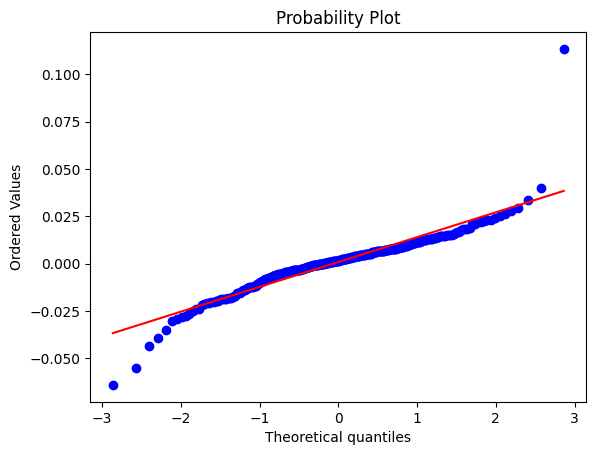

In [39]:
stats.probplot(log_returns, dist ='norm', plot = pylab)
print('Q-Q Plot') 

In [40]:
log_returns.plot(kind = 'box').update_layout(autosize = False, width = 500, height = 300)

In [46]:
ks_stat, p_value = stats.kstest(log_returns,'norm', args = (log_returns.mean(),log_returns.std()))
print(ks_stat, p_value)
if p_value >0.05:
    print('Probably Gaussian')
else :
    print('Probably NOT Gaussian')

0.10485091042200403 0.001299549617004791
Probably NOT Gaussian


In [42]:
sw_stat, p_value = stats.shapiro(log_returns)
print(sw_stat, p_value)
if p_value >0.05:
    print('Probably Gaussian')
else :
    print('Probably NOT Gaussian')

0.8743796428480495 9.280222481851305e-16
Probably NOT Gaussian
